In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler


In [54]:
df=pd.read_csv('standard_scaler_dataset.csv')
df

# Here numerical columns values are in different range so here we use Scaling preprocessing Technique

,Age,Salary,Experience
0,56,32695,3
1,46,78190,7
2,32,35258,6
3,60,117538,8
4,25,69504,27
...,...,...,...
95,24,96842,23
96,26,91373,10
97,41,36776,3
98,18,122787,7


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         100 non-null    int64
 1   Salary      100 non-null    int64
 2   Experience  100 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


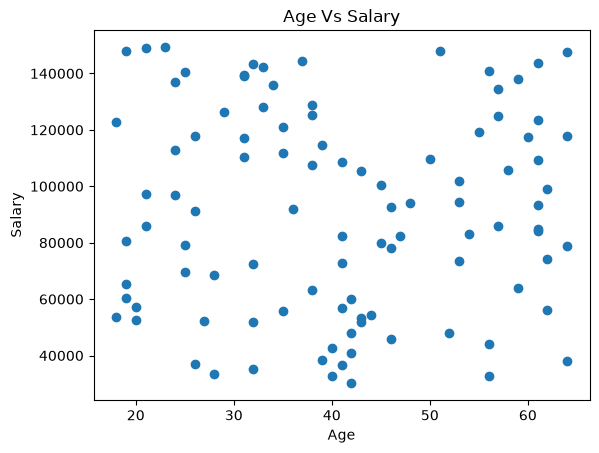

In [56]:
plt.scatter(df['Age'],df['Salary'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age Vs Salary')
plt.show()

In [57]:
x=df.drop(columns=['Experience'])
y=df['Experience']

<Axes: >

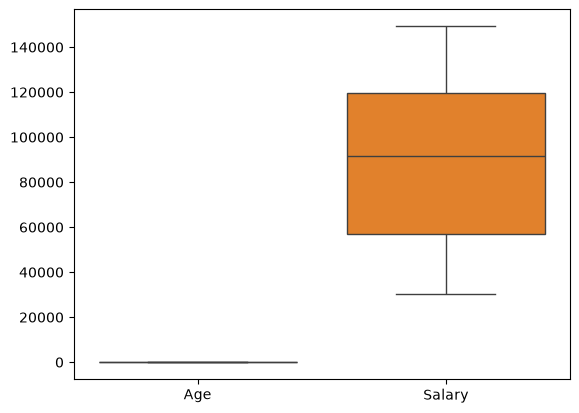

In [58]:
sns.boxplot(x)


In [59]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

### Linear_Regression

In [60]:
model = LinearRegression()

model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.06,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Age','Salary']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.382
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [61]:
# Train Data

ytrain_predicted = model.predict(xtrain)
ytrain_predicted


print(r2_score(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))

0.026809335152035096
8.873527378865543
8.004486811628432


In [62]:
# Test Data

ytest_predicted = model.predict(xtest)

print(r2_score(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))

-0.010710682178010078
8.680350301478084
6.737975322651384


### Polynomial_Regression

In [63]:
Poly=PolynomialFeatures(degree=2)

updated_xtrain = Poly.fit_transform(xtrain)
updated_xtest = Poly.transform(xtest)

In [64]:
model = LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0., 0., 0., 0., 0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[5.67e+10,1.36e+07,4.91e+04,3.74e+03,1.79e+01,0.00e+00]"


In [65]:
# Train Data

ytrain_predicted = model.predict(updated_xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))

0.04311026255104067
8.798897830455926
7.9329646142663055


In [66]:
# Train Data

ytest_predicted = model.predict(updated_xtest)

print(r2_score(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))


-0.013446507014856834
8.692090490667798
6.765852547799571


### Scaling Technique (Before applying Scaling Technique we check outliers)

In [67]:
scaling = StandardScaler()

xtrain_scaled = scaling.fit_transform(xtrain)
xtrain_scaled 

array([[ 1.58134519,  0.81861106],
       [ 1.4422494 , -0.98672281],
       [-0.15735211,  0.7226131 ],
       [-0.43554367,  0.90745589],
       [ 1.37270151,  0.97881203],
       [-1.47876205, -1.08724622],
       [-1.0614747 , -1.54714885],
       [-1.0614747 ,  0.04297792],
       [-0.92237891, -0.62016127],
       [ 0.81631838, -0.4763687 ],
       [-0.01825632, -0.96485467],
       [ 0.12083946, -1.0651445 ],
       [-0.01825632, -0.49517122],
       [ 0.05129157, -1.42875721],
       [-1.61785783, -1.05472137],
       [-0.2269    , -0.78077099],
       [ 0.32948314,  0.07947349],
       [-1.40921416, -0.11915002],
       [ 1.37270151,  0.56664562],
       [-0.15735211, -1.5038797 ],
       [-0.29644789,  1.58644875],
       [ 1.58134519, -1.5121131 ],
       [-0.36599578,  0.0571382 ],
       [-1.20057048,  0.20265336],
       [ 1.37270151,  0.10026137],
       [ 1.37270151,  1.56691632],
       [-0.57463946,  1.52796824],
       [-0.85283102,  1.06429927],
       [-1.54830994,

In [68]:
xtest_scaled = scaling.transform(xtest)

In [69]:
scaling.mean_

array([4.1262500e+01, 8.9900975e+04])

In [70]:
scaling.var_

array([2.06743594e+02, 1.17311239e+09])

In [71]:
int(xtrain_scaled[:,1].mean())

0

In [72]:
xtrain_scaled[:,1].std()

np.float64(1.0)

In [73]:
xtrain_scaled[:,0].std()

np.float64(1.0)

In [74]:
scaling = RobustScaler()
scaling.fit_transform(xtrain)

array([[ 0.86792453,  0.48120406],
       [ 0.79245283, -0.53673172],
       [-0.0754717 ,  0.4270757 ],
       [-0.22641509,  0.53129913],
       [ 0.75471698,  0.57153323],
       [-0.79245283, -0.59341175],
       [-0.56603774, -0.85272741],
       [-0.56603774,  0.04386405],
       [-0.49056604, -0.33004634],
       [ 0.45283019, -0.24896904],
       [ 0.        , -0.52440139],
       [ 0.0754717 , -0.58094972],
       [ 0.        , -0.25957083],
       [ 0.03773585, -0.78597239],
       [-0.86792453, -0.57507264],
       [-0.11320755, -0.42060598],
       [ 0.18867925,  0.06444205],
       [-0.75471698, -0.04755163],
       [ 0.75471698,  0.33913358],
       [-0.0754717 , -0.82833014],
       [-0.1509434 ,  0.91414861],
       [ 0.86792453, -0.83297253],
       [-0.18867925,  0.05184832],
       [-0.64150943,  0.1338969 ],
       [ 0.75471698,  0.07616327],
       [ 0.75471698,  0.90313526],
       [-0.30188679,  0.88117443],
       [-0.45283019,  0.61973512],
       [-0.83018868,

In [75]:
scaling.center_

array([4.10000e+01, 8.87085e+04])

In [76]:
scaling= MinMaxScaler()
scaling.fit_transform(xtrain)

array([[1.        , 0.73090345],
       [0.95652174, 0.20073565],
       [0.45652174, 0.70271197],
       [0.36956522, 0.75699428],
       [0.93478261, 0.77794926],
       [0.04347826, 0.1712152 ],
       [0.17391304, 0.03615677],
       [0.17391304, 0.50312524],
       [0.2173913 , 0.30838285],
       [0.76086957, 0.35061004],
       [0.5       , 0.20715762],
       [0.54347826, 0.17770576],
       [0.5       , 0.34508836],
       [0.52173913, 0.07092454],
       [0.        , 0.18076669],
       [0.43478261, 0.261217  ],
       [0.60869565, 0.5138428 ],
       [0.06521739, 0.45551354],
       [0.93478261, 0.6569094 ],
       [0.45652174, 0.04886351],
       [0.41304348, 0.95639238],
       [1.        , 0.04644563],
       [0.39130435, 0.50728366],
       [0.13043478, 0.55001672],
       [0.93478261, 0.51994753],
       [0.93478261, 0.95065634],
       [0.32608696, 0.93921856],
       [0.23913043, 0.80305408],
       [0.02173913, 0.98804777],
       [0.84782609, 0.8727954 ],
       [0.

In [77]:
scaling.transform(xtest)

array([[ 3.69565217e-01,  1.99312361e-01],
       [ 9.34782609e-01,  4.42206617e-01],
       [ 7.17391304e-01,  9.87318980e-01],
       [ 2.82608696e-01,  7.23315414e-01],
       [ 5.21739130e-01, -2.13236618e-02],
       [ 4.34782609e-01,  8.24077647e-01],
       [ 2.17391304e-02,  2.78905265e-01],
       [ 4.34782609e-01,  7.93665492e-01],
       [ 2.17391304e-01,  7.44227521e-03],
       [ 8.26086957e-01,  1.71480996e-05],
       [ 5.00000000e-01,  6.50856119e-01],
       [ 8.91304348e-01,  9.03473348e-01],
       [ 2.82608696e-01,  9.13410671e-01],
       [ 3.04347826e-01,  9.47938370e-01],
       [ 6.08695652e-01,  1.11582684e-01],
       [ 1.52173913e-01,  3.15619346e-01],
       [ 1.52173913e-01,  3.97724447e-01],
       [ 2.82608696e-01,  9.16248682e-01],
       [ 7.60869565e-01,  5.29979165e-01],
       [ 5.86956522e-01,  5.82169406e-01]])